In [17]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

data_dir = Path("../data/raw/gb_wildlife_dataset")

classes = sorted(
    d.name for d in data_dir.iterdir()
    if d.is_dir()
)

class_counts = {
    c: len([
        f for f in (data_dir / c).rglob("*")
        if f.is_file()
    ])
    for c in classes
}

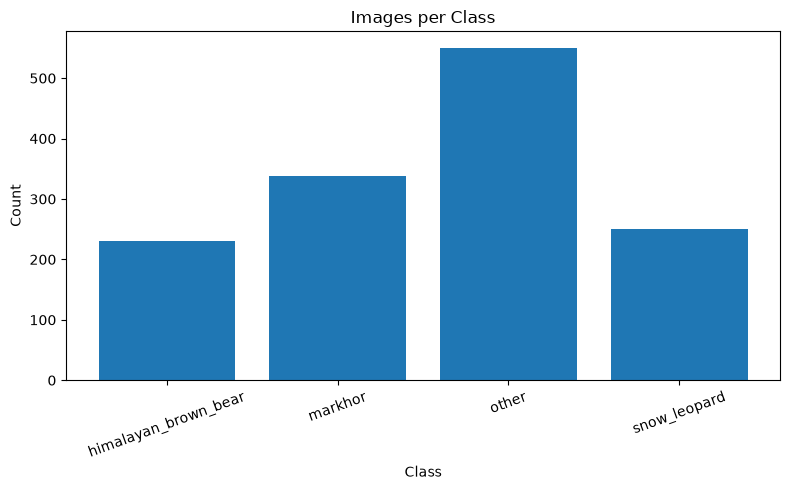

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title("Images per Class")
plt.xlabel("Class")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

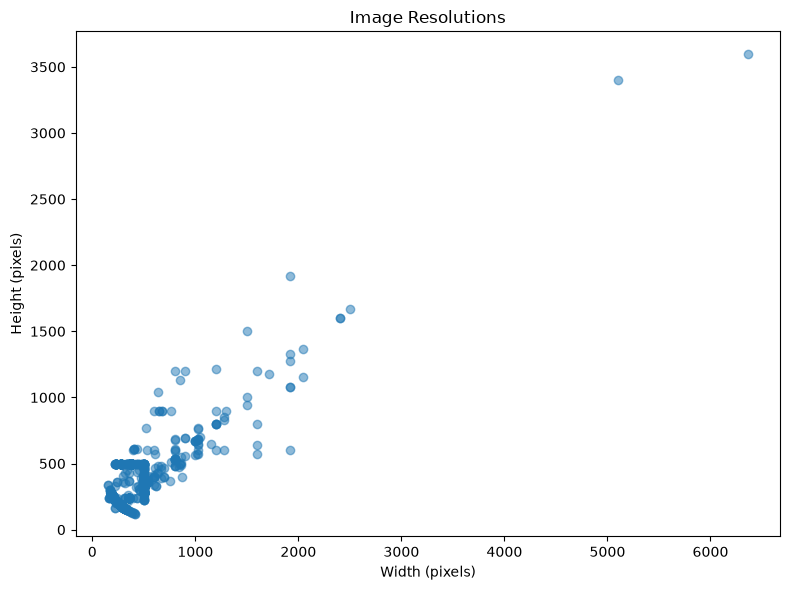

In [19]:
widths = []
heights = []

for c in classes:
    for img_path in (data_dir / c).rglob("*"):

        if not img_path.is_file():
            continue

        try:
            with Image.open(img_path) as img:
                widths.append(img.width)
                heights.append(img.height)
        except Exception:
            pass

plt.figure(figsize=(8, 6))

plt.scatter(
    widths,
    heights,
    alpha=0.5
)

plt.title("Image Resolutions")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")

plt.tight_layout()
plt.show()

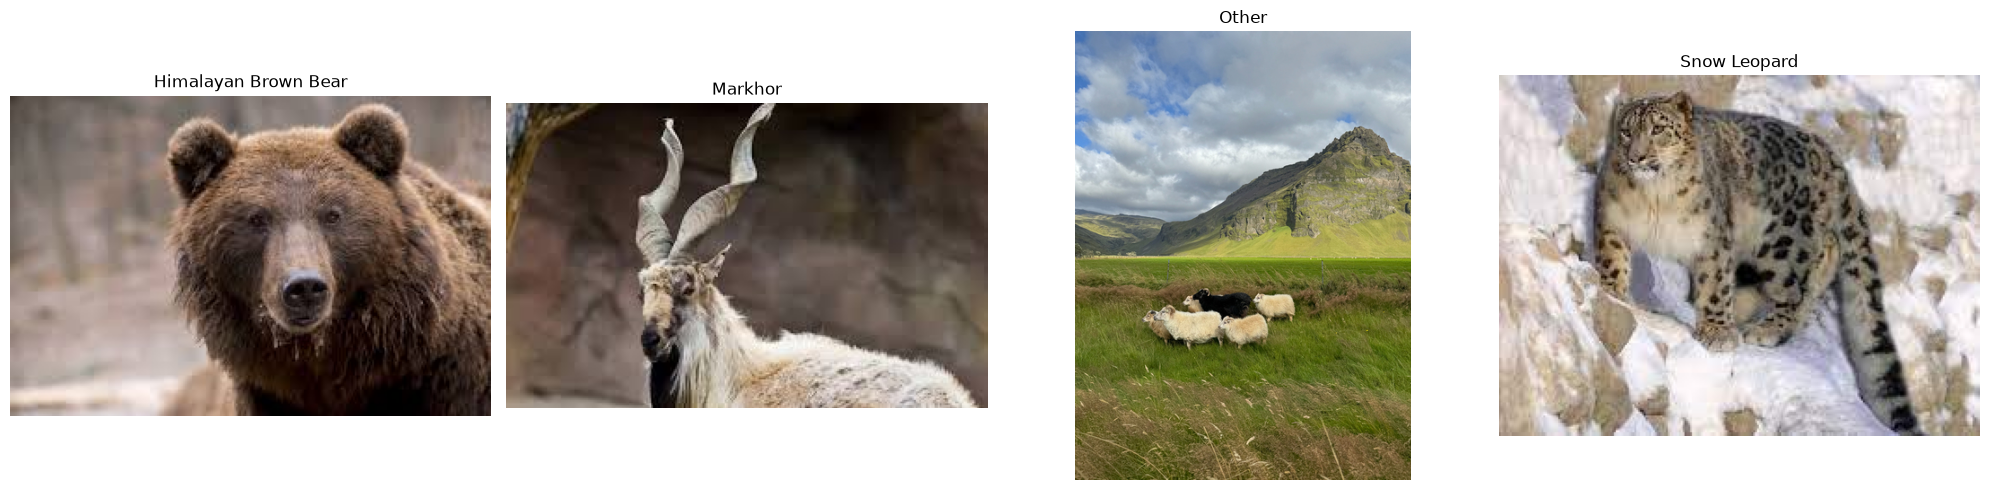

In [20]:
fig, axes = plt.subplots(
    1,
    len(classes),
    figsize=(5 * len(classes), 5)
)

if len(classes) == 1:
    axes = [axes]

for ax, c in zip(axes, classes):

    images = [
        f for f in (data_dir / c).rglob("*")
        if f.is_file()
    ]

    if images:
        sample = random.choice(images)

        with Image.open(sample) as img:
            ax.imshow(img)

    ax.set_title(
        c.replace("_", " ").title()
    )
    ax.axis("off")

plt.tight_layout()
plt.show()